In [71]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# For data modeling
!pip install xgboost
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from xgboost import plot_importance
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
# For metrics and helpful functions
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.tree import plot_tree

## Bank Customer Churn

### This project aims to build Machine Learning and Deep Learning Model to predict the target variable (Exited) which is a binary type.


#### Metrics chosen for this project will be F1 scores
#### Comparing several ML models: 
1) Naive Bayes
2) Logistic Regression
3) Decision Tree
4) XGBoost
5) Artificial Neural Network

#### Methodology:
1) EDA and data preprocessing for features to be fitted to ML models
2) Modeling each ML, train and make predictions
3) Evaluating each model with F1, Accuracy, Recall and Precision scores
4) Discovering problems in models and data to enhance peformance
5) Data Preprocessing - SMOTE and Scaling
6) Re-train each model that peforms poorly due to inability to detect minority class
7) Comparing the result metric scores after scaling
8) Results data visualization based on model and scores
9) Conclusion


In [5]:
file = r"C:\Users\Lim Otto\Downloads\Customer-Churn-Records.csv"

In [7]:
df = pd.read_csv(file) 
df.head(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1,1,5,DIAMOND,484
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0,0,2,SILVER,206
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1,1,2,DIAMOND,282
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0,0,3,GOLD,251
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0,0,3,GOLD,342


In [10]:
corr = df.corr()['Exited']

C:\Users\Lim Otto\AppData\Local\Temp\ipykernel_20360\2392028139.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr = df.corr()['Exited']


In [19]:
df.shape

(10000, 18)

In [20]:
df.isna().sum()

RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

In [24]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


In [26]:
df.duplicated().sum()

0

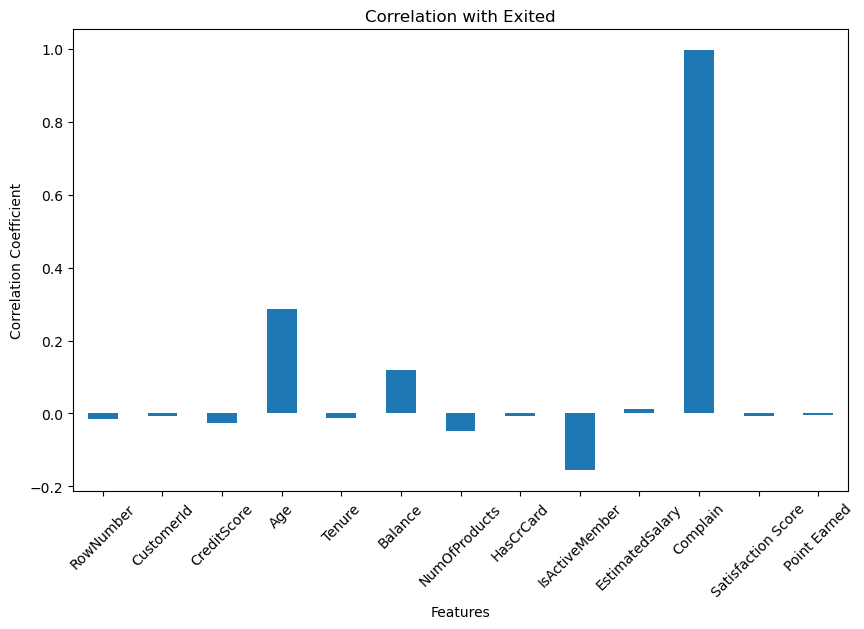

In [27]:
#visualize features correlation
plt.figure(figsize=(10, 6))
corr.drop('Exited').plot(kind='bar')
plt.title('Correlation with Exited')
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45)
plt.show()

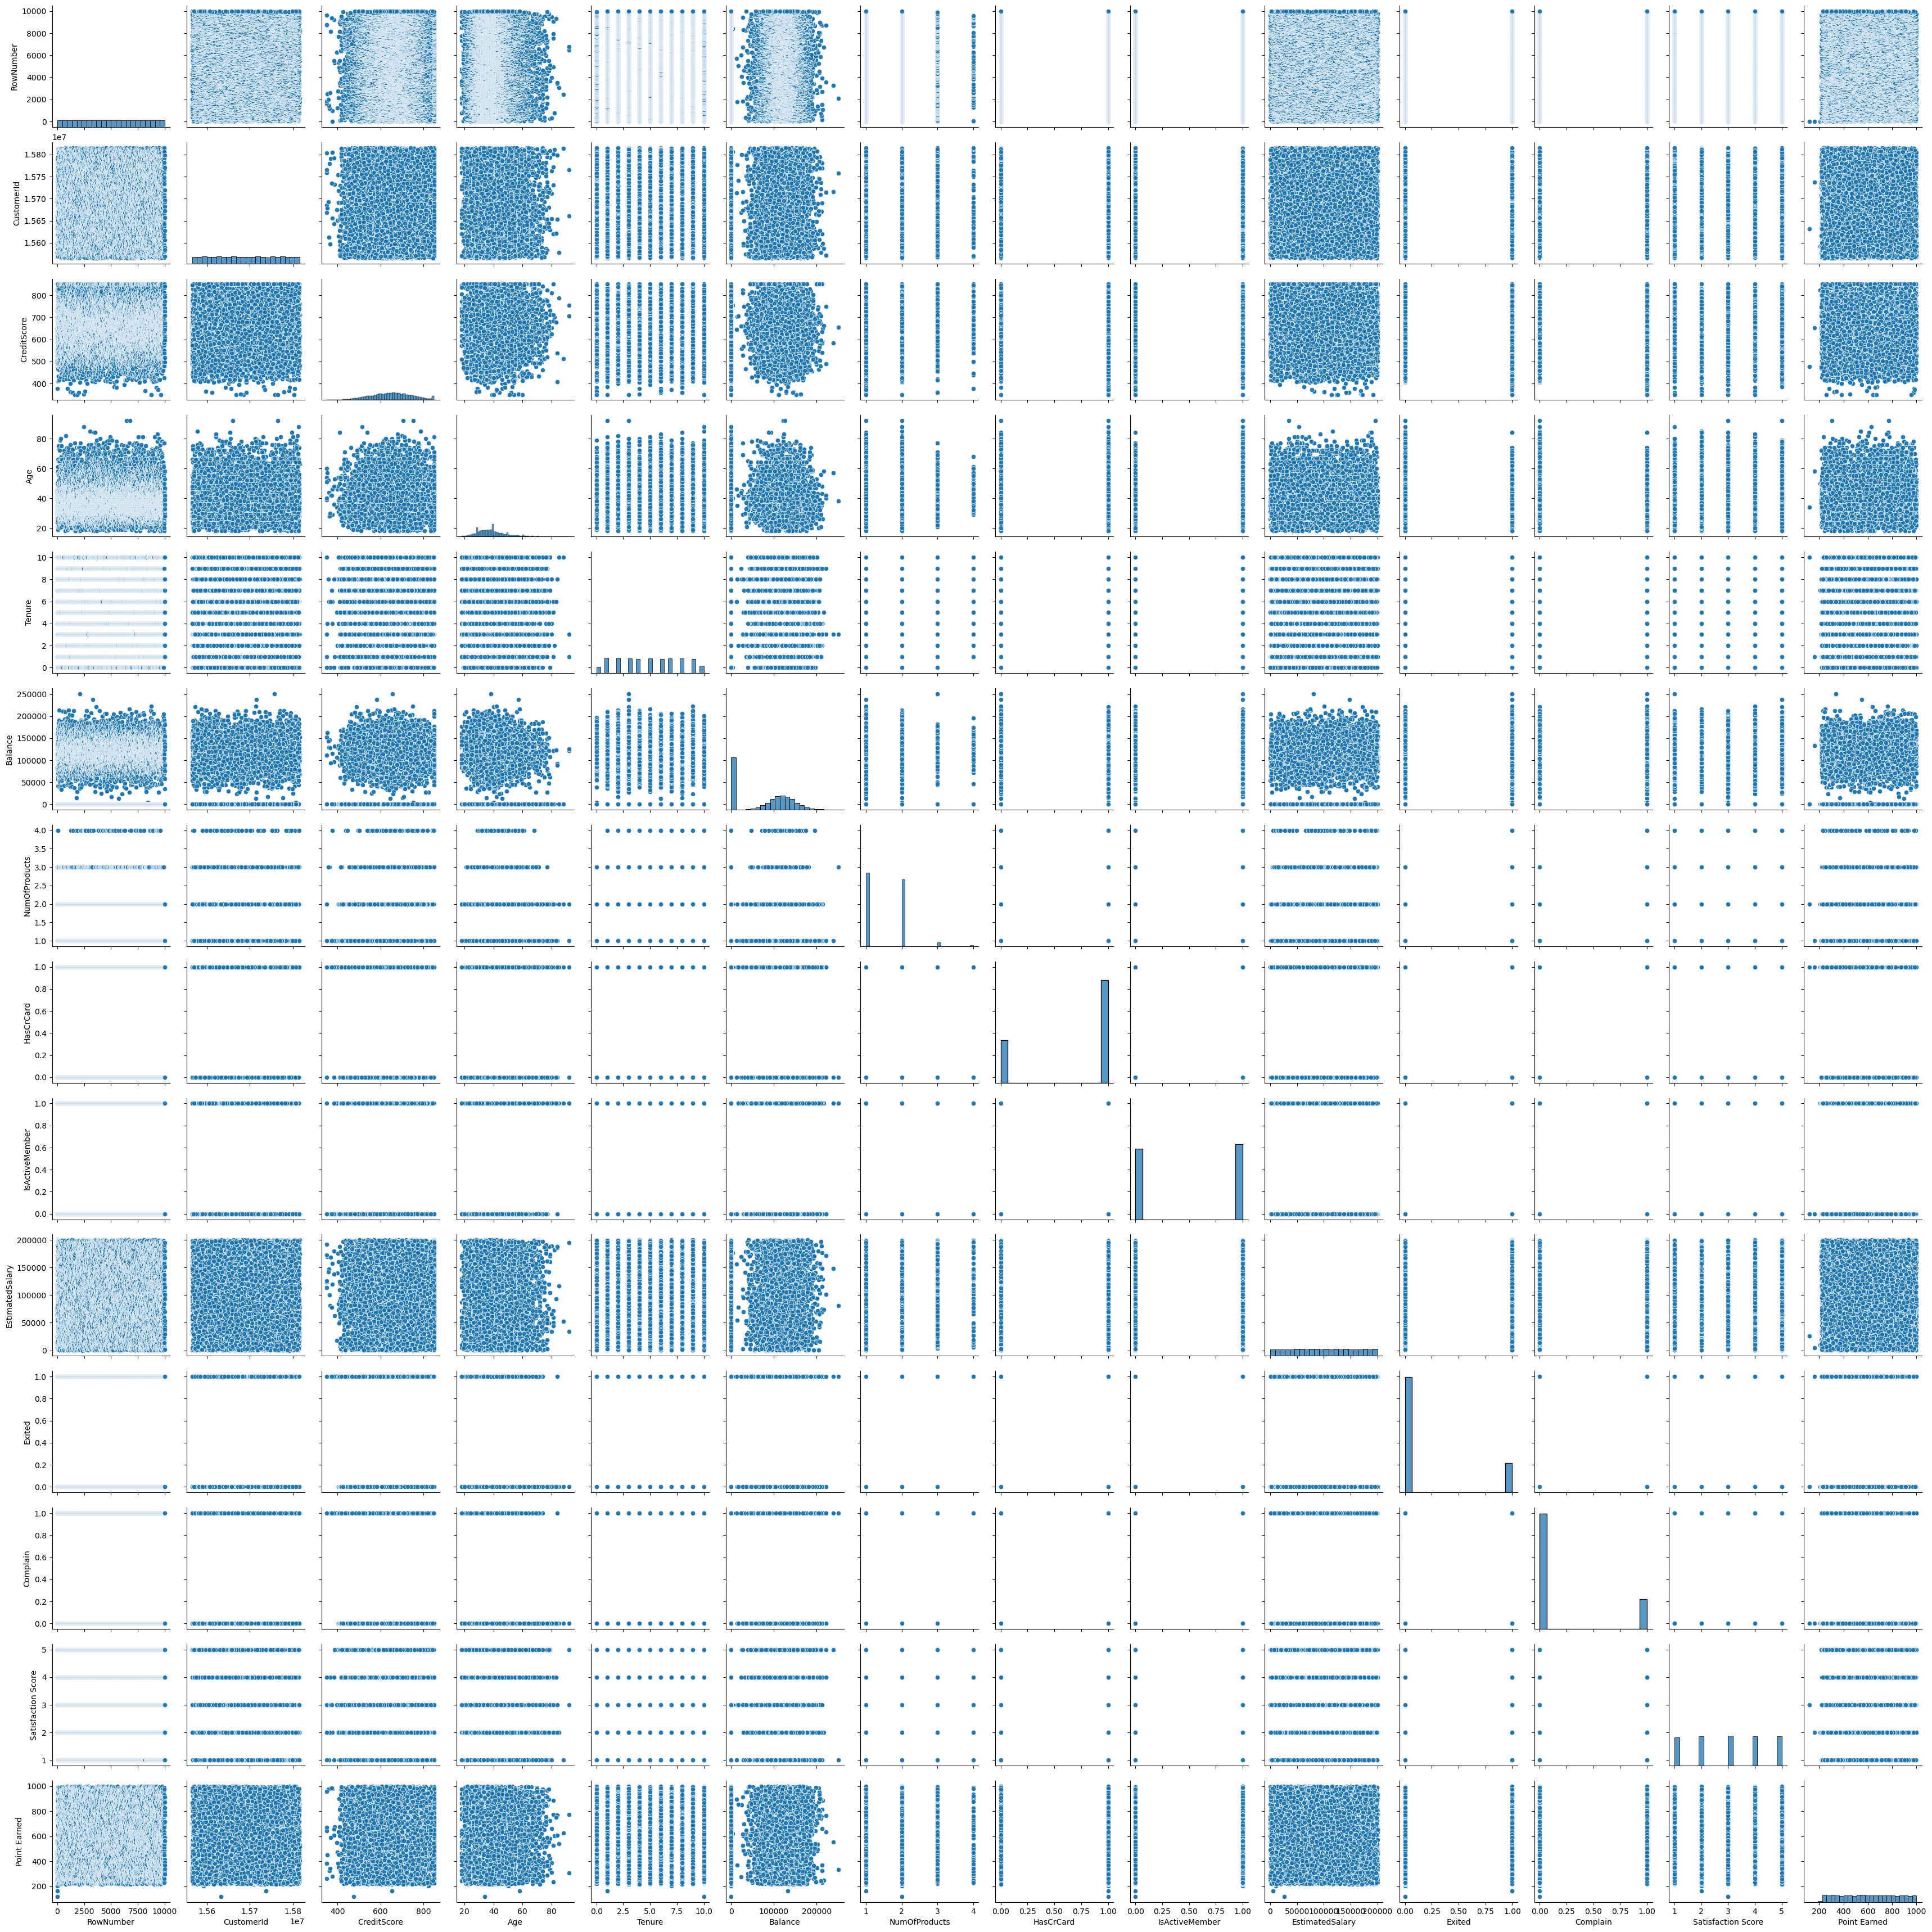

In [22]:
sns.pairplot(df)
plt.show()

In [34]:
#create function for boxplot to detect outliers in features
def plot_boxplot(df, column_name, figsize=(8, 6)):
    sns.boxplot(x=df[column_name])
    plt.title(f'Boxplot of {column_name}')
    plt.xlabel(column_name)
    plt.show()

In [36]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain',
       'Satisfaction Score', 'Card Type', 'Point Earned'],
      dtype='object')

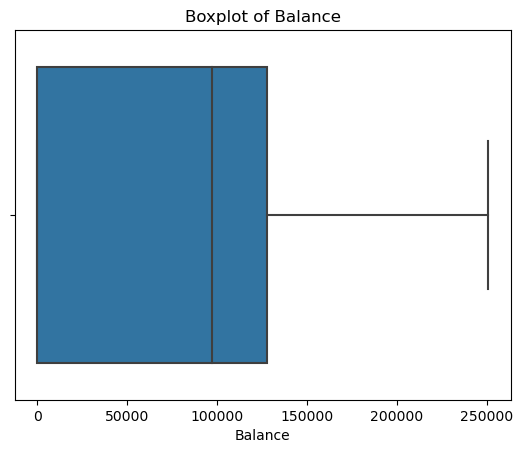

In [35]:
plot_boxplot(df, 'Balance')


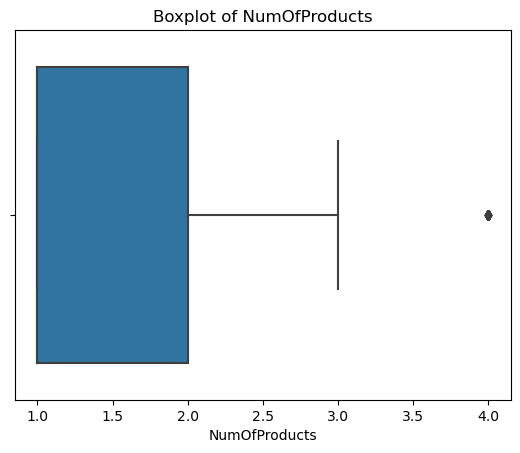

In [37]:
plot_boxplot(df, 'NumOfProducts')

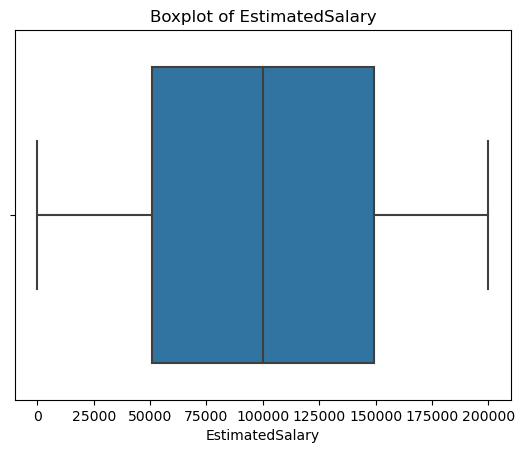

In [38]:
plot_boxplot(df, 'EstimatedSalary')

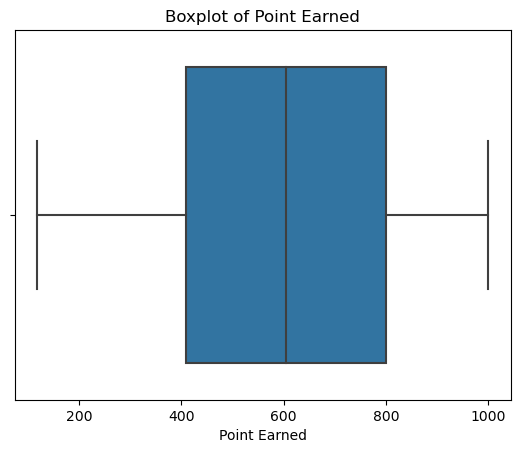

In [39]:
plot_boxplot(df, 'Point Earned')

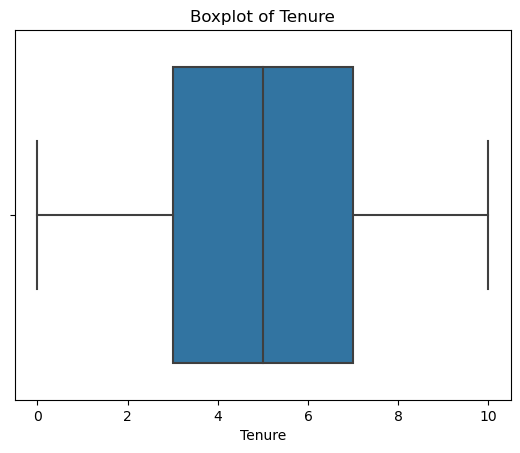

In [45]:
plot_boxplot(df, 'Tenure')

In [43]:
#Create a function to plot histogram to visualize distribution of features
def plot_histogram(df, columns=None, bins=10):
    if columns is None:
        columns= df.select_dtypes(include=[np.number]).columns.tolist()
    for column in columns:
        plt.figure(figsize=(10, 6))
        plt.hist(df[column], bins=bins, edgecolor='k', alpha=0.7)
        plt.title(f'Histogram of {column}')
        plt.xlabel(column)
        plt.ylabel('Frequency')
        plt.grid(True)
        plt.show()
        

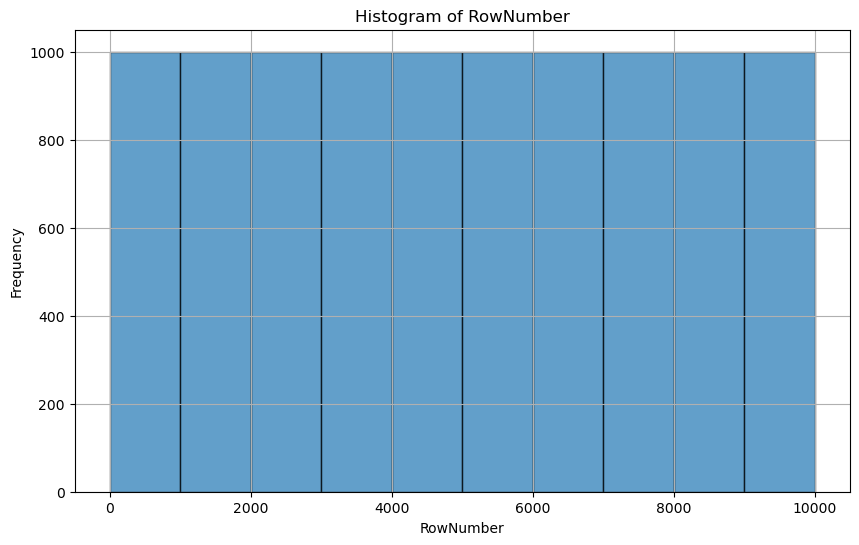

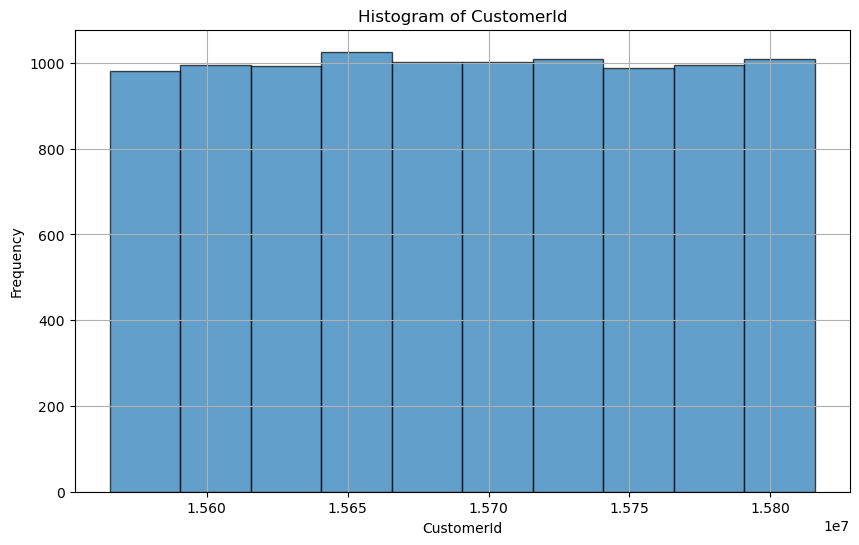

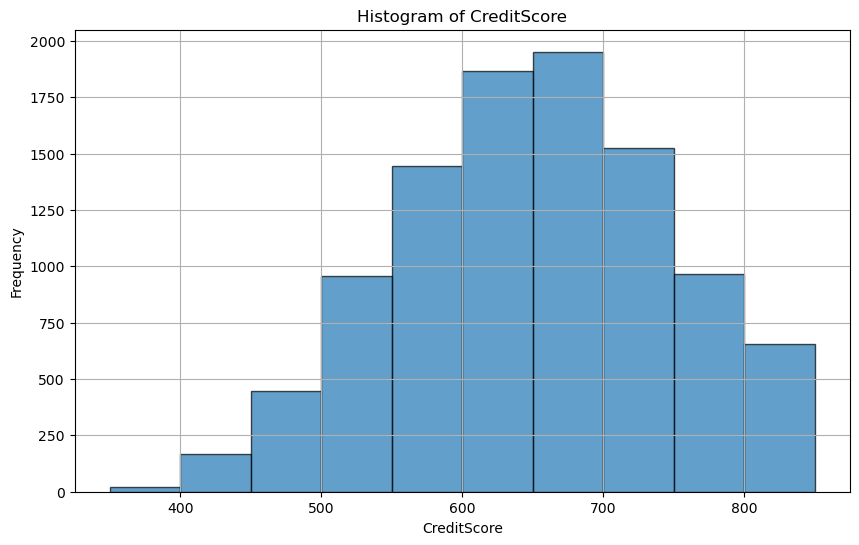

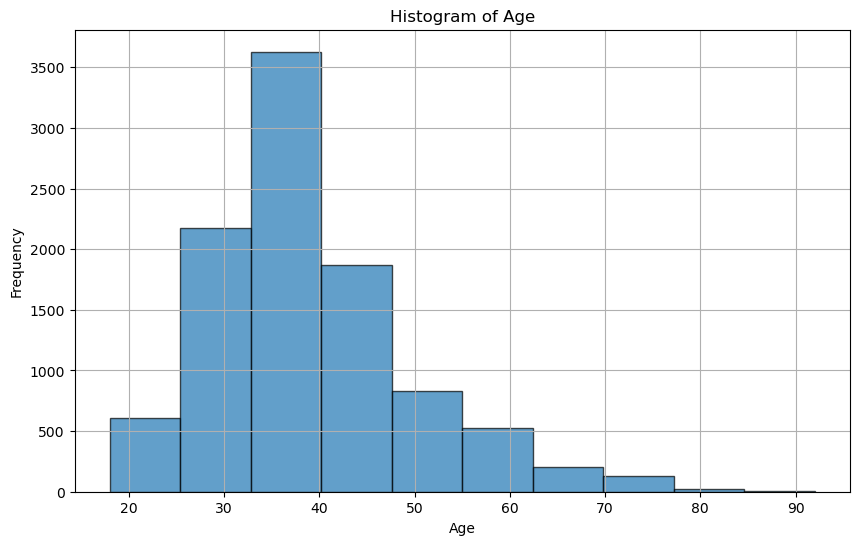

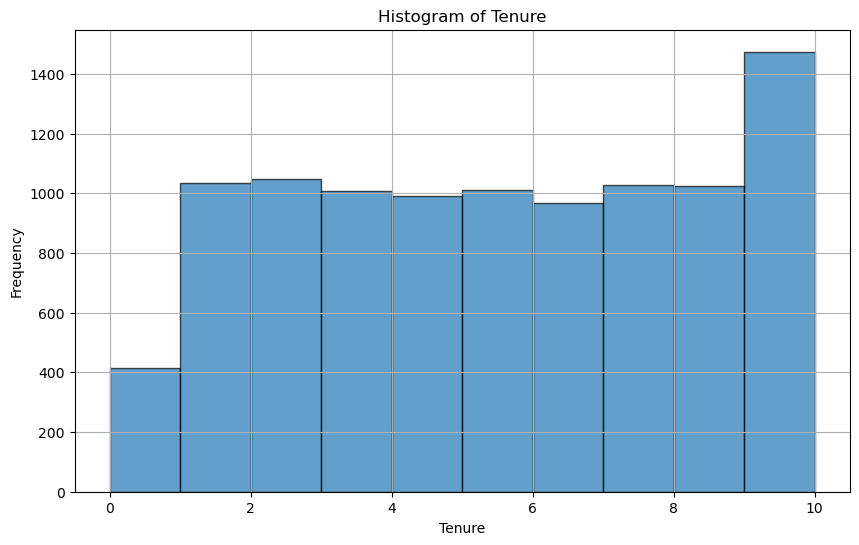

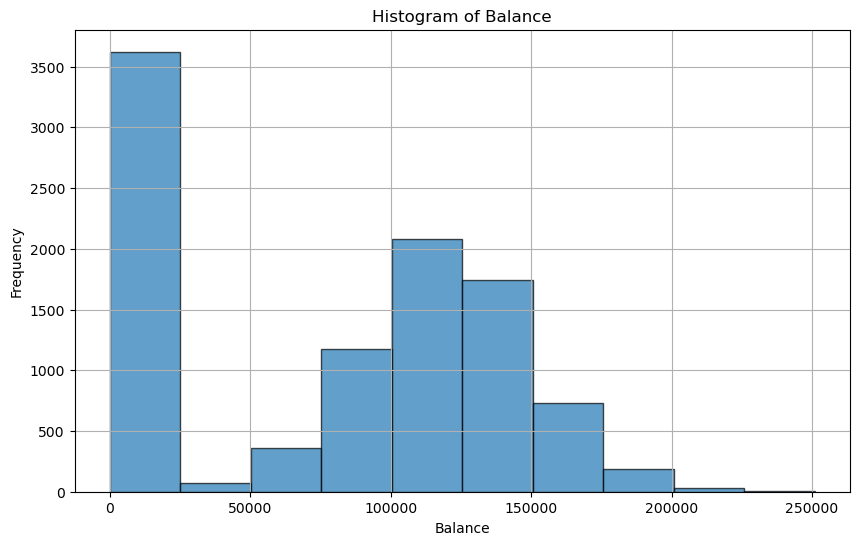

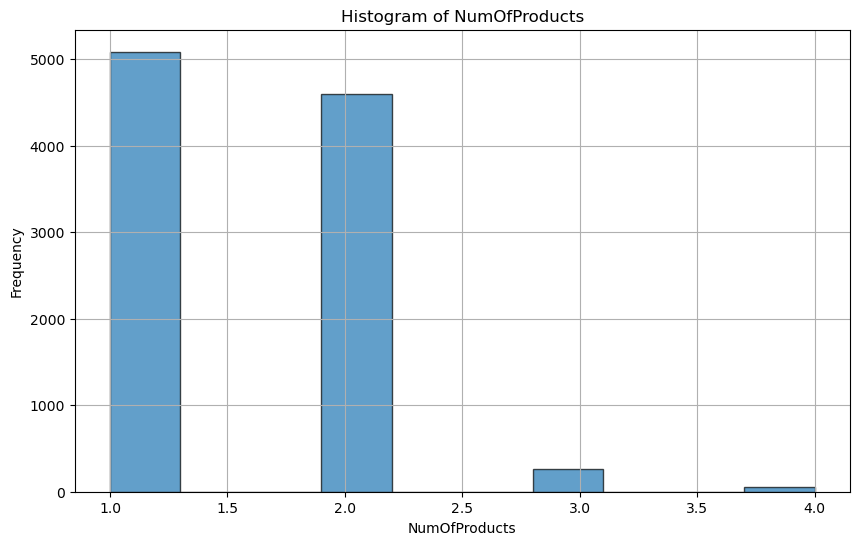

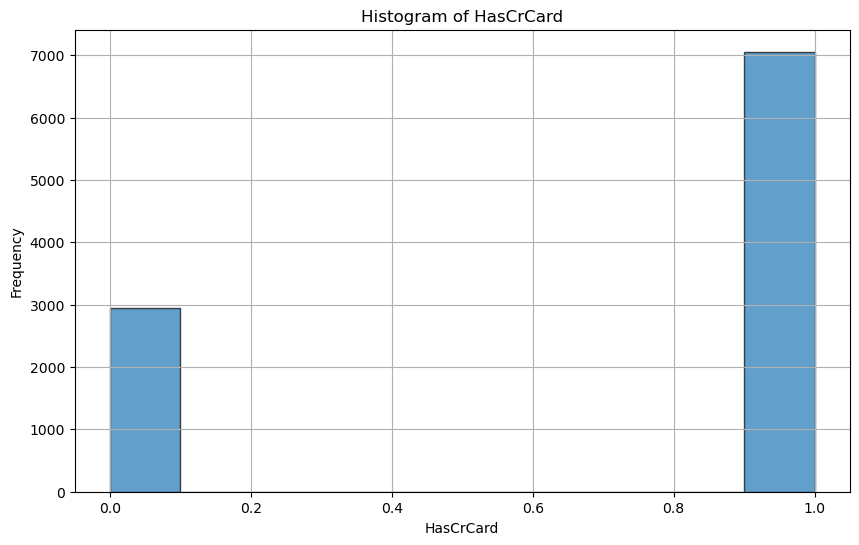

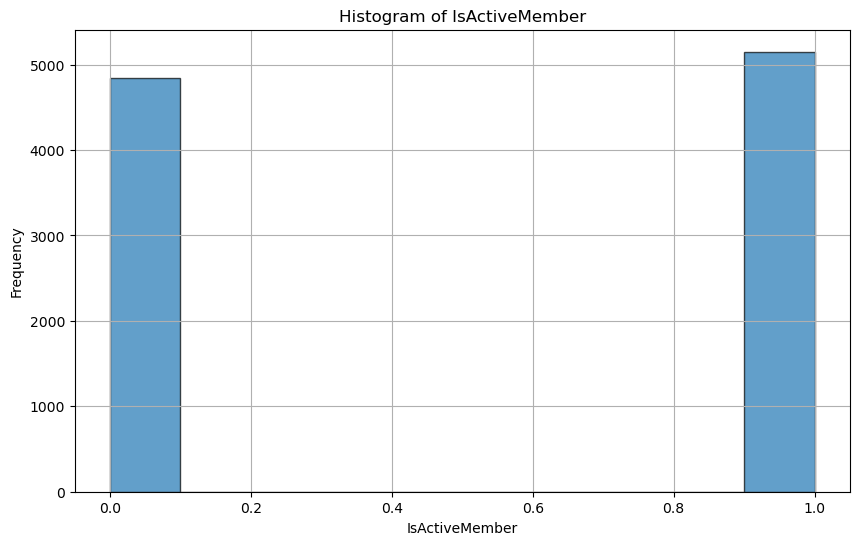

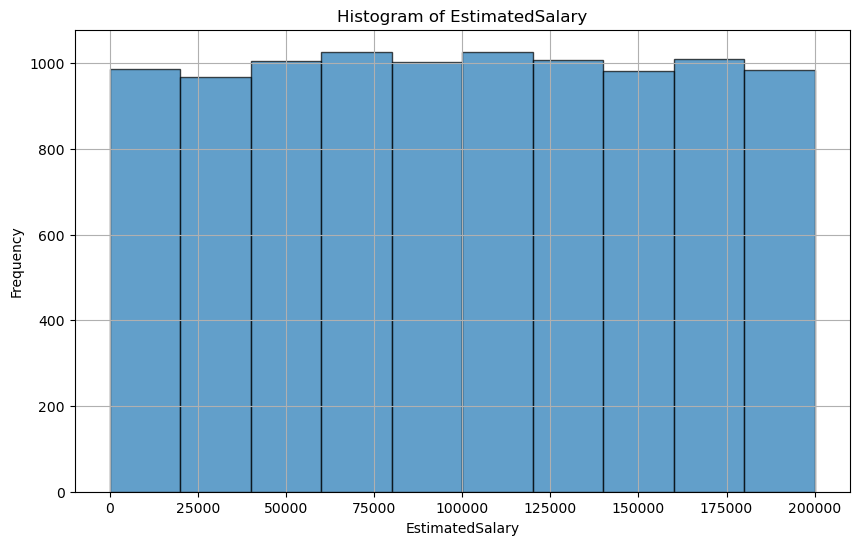

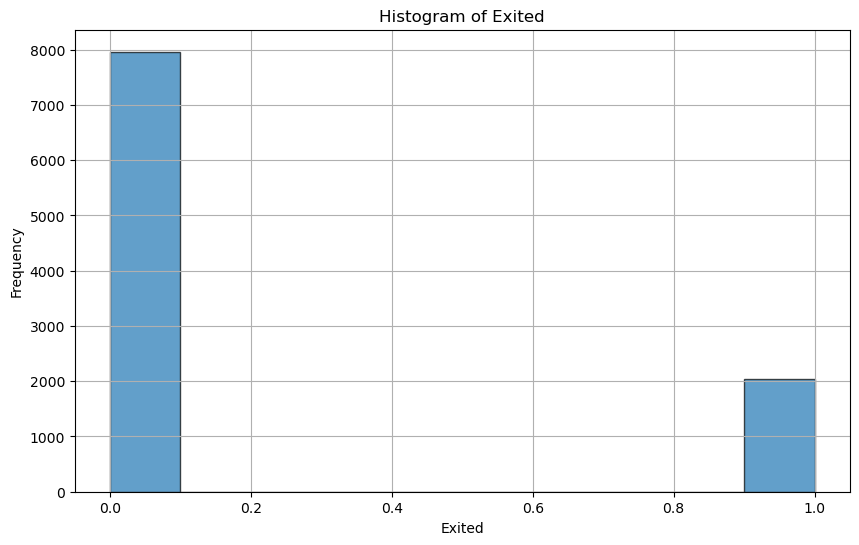

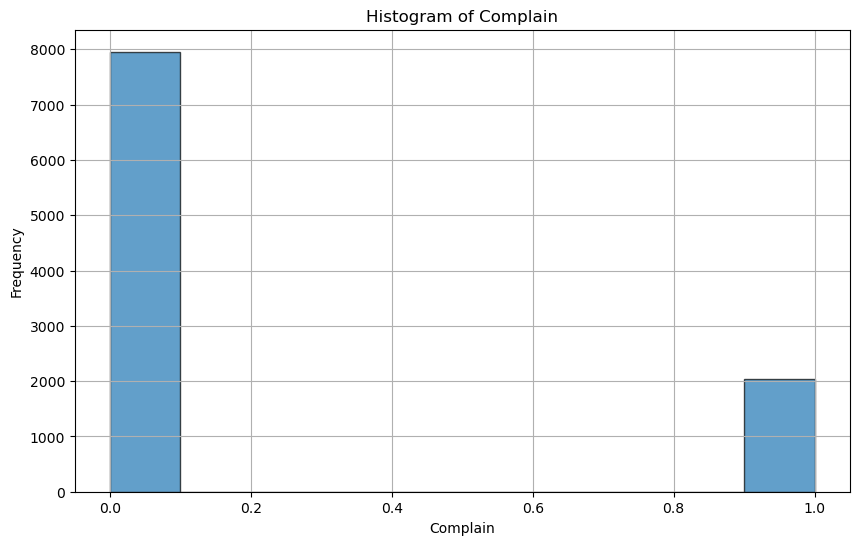

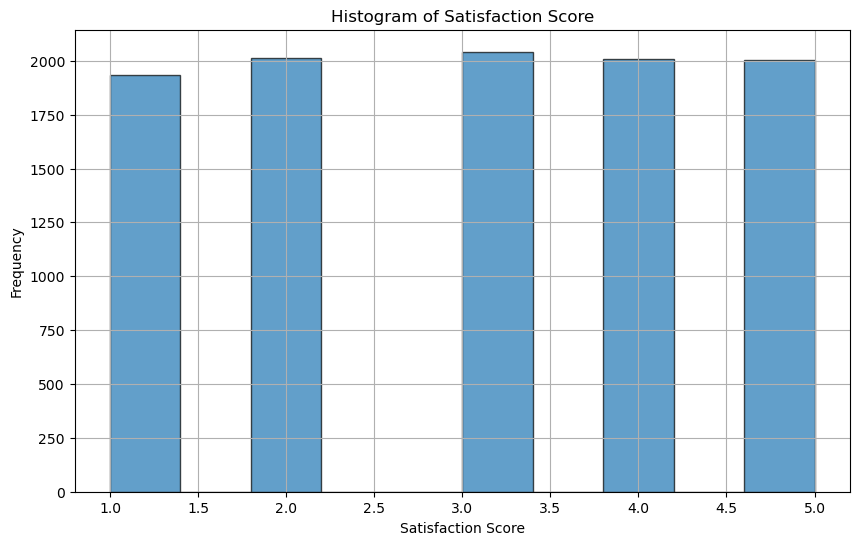

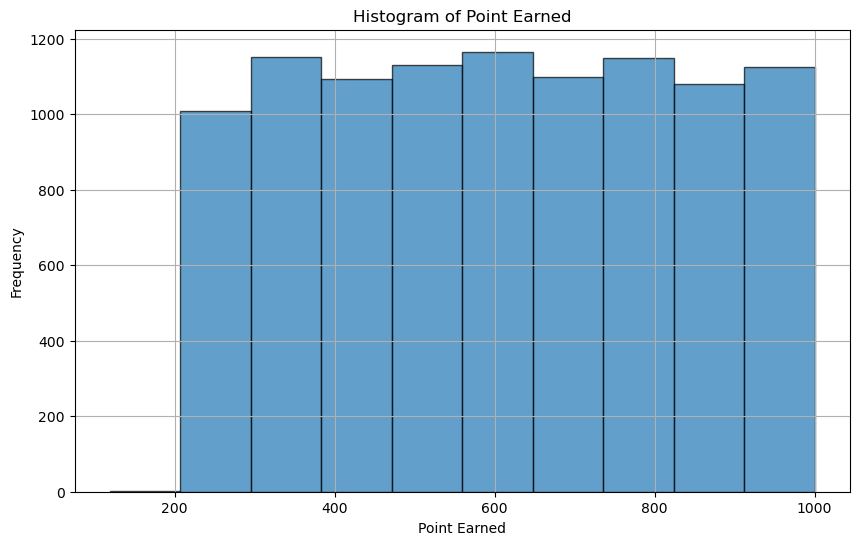

In [44]:
plot_histogram(df)

In [17]:
#checking class balance
df['Exited'].value_counts(normalize=True)*100

0    79.62
1    20.38
Name: Exited, dtype: float64

In [46]:
 # Calculate mean and median satisfaction scores of clients who left and those who stayed

df.groupby(['Exited'])['Satisfaction Score'].agg([np.mean,np.median])

,mean,median
Exited,,
0,3.017960,3.0
1,2.997547,3.0


In [52]:
df1 = df.copy()
df1 = df1.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

In [59]:
df1.shape

(10000, 15)

In [62]:
df1 = pd.get_dummies(df, drop_first=True)

In [63]:
#Assigning target variable with features
X = df1.drop('Exited', axis=1)
y = df1['Exited']

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, stratify=y, random_state=42)

### Naive Bayes Model

In [65]:
#Modeling Naive Bayes 
gnb = GaussianNB()
gnb.fit(X_train, y_train)
gnb_pred = gnb.predict(X_test)

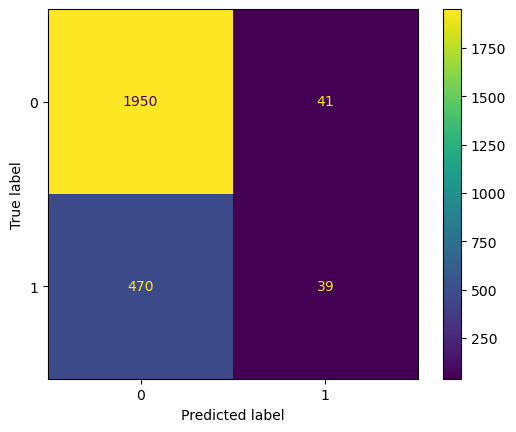

In [66]:
gnb_cm = confusion_matrix(y_test, gnb_pred, labels=gnb.classes_)
# Create display of confusion matrix
gnb_disp = ConfusionMatrixDisplay(confusion_matrix=gnb_cm,
display_labels=gnb.classes_)
# Plot confusion matrix
gnb_disp.plot(values_format='')
# Display plot
plt.show()

In [72]:
print('Accuracy score:', accuracy_score(y_test, gnb_pred))
print('Precision score:', precision_score(y_test, gnb_pred))
print('Recall score:', recall_score(y_test, gnb_pred))
print('F1 score:', f1_score(y_test, gnb_pred))

Accuracy score: 0.7956
Precision score: 0.4875
Recall score: 0.07662082514734773
F1 score: 0.13242784380305603


### Logistic Regression Classifier Model

In [67]:
#Modeling Logistic Regression 
log_reg = LogisticRegression(random_state=42, max_iter=500).fit(X_train, y_train)
log_pred = log_reg.predict(X_test)

C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


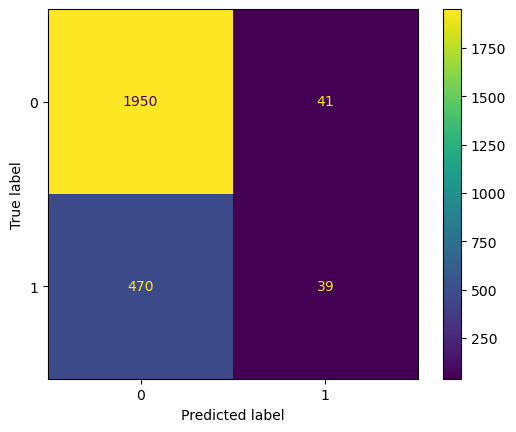

In [73]:
log_cm = confusion_matrix(y_test, gnb_pred, labels=log_reg.classes_)
# Create display of confusion matrix
log_disp = ConfusionMatrixDisplay(confusion_matrix=log_cm,
display_labels=log_reg.classes_)
# Plot confusion matrix
log_disp.plot(values_format='')
# Display plot
plt.show()

In [74]:
print('Accuracy score:', accuracy_score(y_test, log_pred))
print('Precision score:', precision_score(y_test, log_pred))
print('Recall score:', recall_score(y_test, log_pred))
print('F1 score:', f1_score(y_test, log_pred))

Accuracy score: 0.792
Precision score: 0.4126984126984127
Recall score: 0.05108055009823183
F1 score: 0.09090909090909091


### Decision Tree Model

In [75]:
#Modeling Decision Tree round1 (baseline)
tree1 = DecisionTreeClassifier(random_state=0)
tree1.fit(X_train, y_train)


DecisionTreeClassifier(random_state=0)

In [76]:
tree1_pred = tree1.predict(X_test)

In [77]:
print('Accuracy score:', accuracy_score(y_test, tree1_pred))
print('Precision score:', precision_score(y_test, tree1_pred))
print('Recall score:', recall_score(y_test, tree1_pred))
print('F1 score:', f1_score(y_test, tree1_pred))

Accuracy score: 0.998
Precision score: 0.9960629921259843
Recall score: 0.9941060903732809
F1 score: 0.9950835791543756


In [85]:
#Tune DT hyperparameter with gridsearch
tuned_tree = DecisionTreeClassifier(random_state=0)

tree_para = {'max_depth': [4, 5, 6, 8, 10, 12, 15, 20, 30, 40, 50],
            'min_samples_leaf': [2, 5, 10, 20, 50]}
 
scoring = {
    'accuracy': 'accuracy',
    'recall': 'recall',
    'f1': 'f1',
    'precision': 'precision'
}

In [88]:
%%time
dt_clf = GridSearchCV(tuned_tree, tree_para, scoring=scoring, cv=5, refit='f1')
dt_clf.fit(X_train, y_train)



CPU times: total: 1min 29s
Wall time: 3min 26s


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=0),
             param_grid={'max_depth': [4, 5, 6, 8, 10, 12, 15, 20, 30, 40, 50],
                         'min_samples_leaf': [2, 5, 10, 20, 50]},
             refit='f1',
             scoring={'accuracy': 'accuracy', 'f1': 'f1',
                      'precision': 'precision', 'recall': 'recall'})

In [89]:
dt_clf.best_estimator_

DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=0)

In [91]:
dt_clf.best_params_

{'max_depth': 4, 'min_samples_leaf': 10}

In [95]:
#Design function to display each models metrics and scores
def make_result(model_name, model_object):
    cv_results=pd.DataFrame(model_object.cv_results_)
    f1 = cv_results['mean_test_f1'].max()
    recall = cv_results['mean_test_recall'].max()
    precision = cv_results['mean_test_precision'].max()
    accuracy = cv_results['mean_test_accuracy'].max()
    table = pd.DataFrame({'Model':[model_name],
                         'F1': [f1],
                         'Recall': [recall],
                         'Precision': [precision],
                         'Accuracy': [accuracy]
                         })
    return table

In [97]:
result_table = make_result('Tuned Tree', dt_clf)
result_table

,Model,F1,Recall,Precision,Accuracy
0,Tuned Tree,0.996736,0.998693,0.99479,0.998667


### Ensamble method Random Forest model

In [104]:
# Instantiate Random Forest model
rf = RandomForestClassifier(random_state=0)

rf_param = {'max_depth': [2, 3, 5, 7],
           'min_samples_leaf': [1, 2, 3],
           'min_samples_split': [2, 3, 4],
           'max_features': [3, 5, 7],
           'n_estimators': [50, 75, 100]}
scoring = {
    'accuracy': 'accuracy',
    'recall': 'recall',
    'f1': 'f1',
    'precision': 'precision'
}


In [105]:
%%time
rf_cv = GridSearchCV(rf, rf_param, scoring=scoring, cv=5, refit='f1')
rf_cv.fit(X_train, y_train)

C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\m

C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\m

C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\m

C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\m

C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\m

...

C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\m

C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\m

C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\m

CPU times: total: 10min 1s
Wall time: 22min 21s


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=0),
             param_grid={'max_depth': [2, 3, 5, 7], 'max_features': [3, 5, 7],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 3, 4],
                         'n_estimators': [50, 75, 100]},
             refit='f1',
             scoring={'accuracy': 'accuracy', 'f1': 'f1',
                      'precision': 'precision', 'recall': 'recall'})

In [106]:
rf_cv.best_estimator_

RandomForestClassifier(max_depth=2, max_features=3, n_estimators=50,
                       random_state=0)

In [111]:
rf_pred = rf_cv.predict(X_test)

In [115]:
print('Accuracy score:', accuracy_score(y_test, rf_pred))
print('Precision score:', precision_score(y_test, rf_pred))
print('Recall score:', recall_score(y_test, rf_pred))
print('F1 score:', f1_score(y_test, rf_pred))

Accuracy score: 0.7964
Precision score: 0.0
Recall score: 0.0
F1 score: 0.0


C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [114]:
rf_results = make_result('Random Forest', rf_cv)
rf_results

,Model,F1,Recall,Precision,Accuracy
0,Random Forest,0.0,0.0,0.0,0.796133


In [119]:
#Hyper parameter tuned rf
from sklearn.model_selection import PredefinedSplit
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.25, stratify=y_train, random_state=42)

#making a list of len(X_train) where each elements contain 0 or -1
split_index = [0 if x in X_val.index else -1 for x in X_train.index]
rf2= RandomForestClassifier(random_state=0)

rf2_param = {'max_depth': [2, 3, 5, 7],
           'min_samples_leaf': [1, 2, 3],
           'min_samples_split': [2, 3, 4],
           'max_features': [3, 5, 7],
           'n_estimators': [50, 75, 100]}
scoring = {
    'accuracy': 'accuracy',
    'recall': 'recall',
    'f1': 'f1',
    'precision': 'precision'
}
custom_split = PredefinedSplit(split_index)


In [120]:
%%time
rf_val = GridSearchCV(rf2, rf2_param, scoring=scoring, cv=custom_split, refit='f1')
rf_val.fit(X_train, y_train)

C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\m

C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\m

C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\m

C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\m

C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\m

...

C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\m

C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\m

C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\m

CPU times: total: 2min 30s
Wall time: 4min 35s


GridSearchCV(cv=PredefinedSplit(test_fold=array([-1, -1, ...,  0, -1])),
             estimator=RandomForestClassifier(random_state=0),
             param_grid={'max_depth': [2, 3, 5, 7], 'max_features': [3, 5, 7],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 3, 4],
                         'n_estimators': [50, 75, 100]},
             refit='f1',
             scoring={'accuracy': 'accuracy', 'f1': 'f1',
                      'precision': 'precision', 'recall': 'recall'})

In [121]:
rf_val.best_estimator_

RandomForestClassifier(max_depth=2, max_features=3, n_estimators=50,
                       random_state=0)

In [122]:
rf_val_results = make_result('Random Forest Tuned', rf_val)
rf_val_results

,Model,F1,Recall,Precision,Accuracy
0,Random Forest Tuned,0.0,0.0,0.0,0.796267


### XGBoost Model 
#### Using RandomizedSearch instead of GridSearch due to computing limitation

In [129]:
#Modeling XGBoost
#using randomized search as gridsearch took 2hr and crashes
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBClassifier(objective='binary:logistic', random_state=0)
xgb_param = {'max_depth': [2, 3, 5],
            'min_child_weight': [1, 3, 5],
            'learning_rate': [0.1, 0.2, 0.3],
            'n_estimators':[50, 75, 100]}

scoring = {
    'accuracy': 'accuracy',
    'recall': 'recall',
    'f1': 'f1',
    'precision': 'precision'
}

In [133]:
xgb_cv = RandomizedSearchCV(xgb, xgb_param, scoring=scoring, cv=5, refit='f1', n_iter=50, verbose=2, n_jobs=-1)

#crashes multiple times after 3hr of fitting xgb

In [136]:
%%time
xgb_cv.fit(X_train, y_train, verbose=True)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
CPU times: total: 14.7 s
Wall time: 14min 43s


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           gamma=None, grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning_rate...
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None,
                                           random_state=0, ...),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'learning_rate': [0.1, 0.2, 0.3],
                                        'max_depth': [2, 3, 5],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [50, 75, 100]},
                   refit='f1',
                   scoring={'accuracy': 'accuracy', 'f1': 'f1',
                            'precision': 'precision', 'recall': 'recall'},
                   verbose=2)

In [137]:
xgb_pred = xgb_cv.predict(X_test)


<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

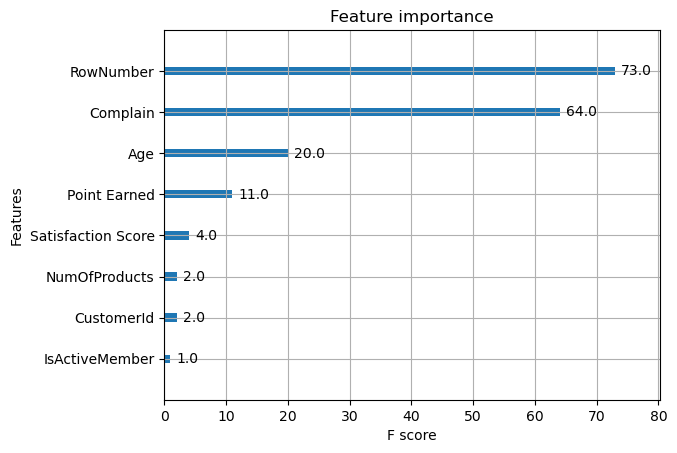

In [138]:
plot_importance(xgb_cv.best_estimator_)

In [139]:
xgb_result = make_result('XGBoost', xgb_cv)
xgb_result

,Model,F1,Recall,Precision,Accuracy
0,XGBoost,0.996736,0.998693,0.99479,0.998667


### Neural Network Deep Learning Predictive Model 

In [140]:
#importing tensorflow for deep learning 
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense

In [142]:
#instantiating sequential model
model = Sequential()

#input layer
model.add(Dense(units=32, activation='relu', input_dim=len(X_train.columns)))
#hidden layer
model.add(Dense(units=64, activation='relu'))
model.add(Dense(units=64, activation='relu'))
#output layer
model.add(Dense(units=1, activation='sigmoid'))



C:\Users\Lim Otto\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [149]:
#Compile model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [150]:
%%time
model.fit(X_train, y_train, epochs=200, batch_size=32, callbacks=[early_stopping]) 

Epoch 1/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8001 - loss: 0.5003
Epoch 2/200
 47/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7757 - loss: 0.5336

C:\Users\Lim Otto\anaconda3\Lib\site-packages\keras\src\callbacks\early_stopping.py:155: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7901 - loss: 0.5140
Epoch 3/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7997 - loss: 0.5009
Epoch 4/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8031 - loss: 0.4962
Epoch 5/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7878 - loss: 0.5170
Epoch 6/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7995 - loss: 0.5011
Epoch 7/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7965 - loss: 0.5052
Epoch 8/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7958 - loss: 0.5062
Epoch 9/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7973 - loss: 0.5041
Epoch 10/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8016 - loss: 0.4983
Epoch 11/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7946 - loss: 0.5078
Epoch 12/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7961 - loss: 0.5057
Epoch 13/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/ste

235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7979 - loss: 0.5034
Epoch 70/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7892 - loss: 0.5151
Epoch 71/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8006 - loss: 0.4996
Epoch 72/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7906 - loss: 0.5133
Epoch 73/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7949 - loss: 0.5074
Epoch 74/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7911 - loss: 0.5125
Epoch 75/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8024 - loss: 0.4972
Epoch 76/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7938 - loss: 0.5089
Epoch 77/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7869 - loss: 0.5182
Epoch 78/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7995 - loss: 0.5011
Epoch 79/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7954 - loss: 0.5067
Epoch 80/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 

235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7973 - loss: 0.5041
Epoch 136/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7912 - loss: 0.5124
Epoch 137/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7963 - loss: 0.5056
Epoch 138/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7982 - loss: 0.5029
Epoch 139/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7889 - loss: 0.5155
Epoch 140/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7954 - loss: 0.5067
Epoch 141/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7982 - loss: 0.5029
Epoch 142/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7998 - loss: 0.5007
Epoch 143/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7938 - loss: 0.5089
Epoch 144/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7912 - loss: 0.5125
Epoch 145/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7952 - loss: 0.5070
Epoch 146/200
235/235 ━━━━━━━━━━━━━

In [151]:
tf_pred = model.predict(X_test)
tf_pred = [0 if val <0.5 else 1 for val in tf_pred]

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [152]:
print('Accuracy score:', accuracy_score(y_test, tf_pred))
print('Precision score:', precision_score(y_test, tf_pred))
print('Recall score:', recall_score(y_test, tf_pred))
print('F1 score:', f1_score(y_test, tf_pred))

Accuracy score: 0.7964
Precision score: 0.0
Recall score: 0.0
F1 score: 0.0


C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [154]:
accuracy = accuracy_score(y_test, tf_pred)
precision =  precision_score(y_test, tf_pred)
recall = recall_score(y_test, tf_pred)
f1 = f1_score(y_test, tf_pred)
tf_results = pd.DataFrame({'Model':[model],
                          'F1': [f1],
                          'Recall': [recall],
                          'Precision': [precision],
                          'Accuracy': [accuracy]})

C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [158]:
#concat and compare all result from earlier ML models
all_results = pd.concat([result_table, rf_results, rf_val_results, xgb_result,tf_results], ignore_index=True)
all_results

,Model,F1,Recall,Precision,Accuracy
0,Tuned Tree,0.996736,0.998693,0.99479,0.998667
1,Random Forest,0.000000,0.000000,0.00000,0.796133
2,Random Forest Tuned,0.000000,0.000000,0.00000,0.796267
3,XGBoost,0.996736,0.998693,0.99479,0.998667
4,"<Sequential name=sequential_1, built=True>",0.000000,0.000000,0.00000,0.796400


## Metrics for some models scores 0, this is likely due to it's sensative nature towards class imbalance and unscaled data

### To improve the peformance, further data processing is needed to re-train the models
### Next step: Applying SMOTE on training sets, then scale the X features

In [159]:
#RF, Neural Network scores 0.0 on f1, recall and precision
#might due to class imbalance
#Next step--->1) SMOTE ---> 2) Scaling the features X
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

In [160]:
#Apply SMOTE on split test data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [161]:
scaler = StandardScaler()
scaler.fit_transform(X_train_res)
X_test = scaler.transform(X_test)

In [164]:
#Fit processed data to RF

rf_cv_res = GridSearchCV(rf, rf_param, scoring=scoring, cv=5, refit='f1')
rf_cv_res.fit(X_train_res, y_train_res)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=0),
             param_grid={'max_depth': [2, 3, 5, 7], 'max_features': [3, 5, 7],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 3, 4],
                         'n_estimators': [50, 75, 100]},
             refit='f1',
             scoring={'accuracy': 'accuracy', 'f1': 'f1',
                      'precision': 'precision', 'recall': 'recall'})

In [165]:
rf_cv_res.best_estimator_

RandomForestClassifier(max_depth=7, max_features=3, min_samples_split=3,
                       random_state=0)

In [166]:
rf_cv_res_pred = rf_cv_res.best_estimator_.predict(X_test)

C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [167]:
print('Accuracy score:', accuracy_score(y_test, rf_cv_res_pred))
print('Precision score:', precision_score(y_test, rf_cv_res_pred))
print('Recall score:', recall_score(y_test, rf_cv_res_pred))
print('F1 score:', f1_score(y_test, rf_cv_res_pred))

Accuracy score: 0.9868
Precision score: 0.9666666666666667
Recall score: 0.9685658153241651
F1 score: 0.9676153091265947


In [168]:
rf_cv_res_table = make_result('RF Res', rf_cv_res)
rf_cv_res_table

,Model,F1,Recall,Precision,Accuracy
0,RF Res,0.938388,0.942743,0.942371,0.940638


In [196]:

X_tr_res, X_val_res, y_tr_res, y_val_res = train_test_split(X_train_res, y_train_res, test_size=0.25, stratify=y_train_res, random_state=42)

#making a list of len(X_train) where each elements contain 0 or -1
res_split_index = [0 if x in X_val_res.index else -1 for x in X_train_res.index]

In [197]:
res_custom_split = PredefinedSplit(res_split_index)

In [198]:
%%time
rf_val_res = GridSearchCV(rf2, rf2_param, scoring=scoring, cv=res_custom_split, refit='f1')
rf_val_res.fit(X_train_res, y_train_res)

CPU times: total: 2min 27s
Wall time: 5min 38s


GridSearchCV(cv=PredefinedSplit(test_fold=array([-1, -1, ..., -1, -1])),
             estimator=RandomForestClassifier(random_state=0),
             param_grid={'max_depth': [2, 3, 5, 7], 'max_features': [3, 5, 7],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 3, 4],
                         'n_estimators': [50, 75, 100]},
             refit='f1',
             scoring={'accuracy': 'accuracy', 'f1': 'f1',
                      'precision': 'precision', 'recall': 'recall'})

In [199]:
rf_val_res.best_estimator_

RandomForestClassifier(max_depth=2, max_features=3, min_samples_split=4,
                       random_state=0)

In [200]:
rf_val_res_pred = rf_val_res.best_estimator_.predict(X_test)

C:\Users\Lim Otto\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [201]:
print('Accuracy score:', accuracy_score(y_test, rf_val_res_pred))
print('Precision score:', precision_score(y_test, rf_val_res_pred))
print('Recall score:', recall_score(y_test, rf_val_res_pred))
print('F1 score:', f1_score(y_test, rf_val_res_pred))

Accuracy score: 0.9808
Precision score: 0.9792099792099792
Recall score: 0.925343811394892
F1 score: 0.9515151515151515


In [206]:
rf_val_accuracy = accuracy_score(y_test, rf_val_res_pred)
rf_val_precision =  precision_score(y_test, rf_val_res_pred)
rf_val_recall = recall_score(y_test, rf_val_res_pred)
rf_val_f1 = f1_score(y_test, rf_val_res_pred)
rf_val_results = pd.DataFrame({'Model':[rf_val_res],
                          'F1': [rf_val_f1],
                          'Recall': [rf_val_recall],
                          'Precision': [rf_val_precision],
                          'Accuracy': [rf_val_accuracy]})
rf_val_results

,Model,F1,Recall,Precision,Accuracy
0,"(DecisionTreeClassifier(max_depth=2, max_featu...",0.951515,0.925344,0.97921,0.9808


In [184]:
#instantiate XGBoost on processed data

xgb_cv_res = RandomizedSearchCV(xgb, xgb_param, scoring=scoring, cv=5, refit='f1', n_iter=50, verbose=2, n_jobs=-1)


In [185]:
%%time
xgb_cv_res.fit(X_train_res, y_train_res, verbose=True)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
CPU times: total: 33.3 s
Wall time: 37min 41s


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           gamma=None, grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning_rate...
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None,
                                           random_state=0, ...),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'learning_rate': [0.1, 0.2, 0.3],
                                        'max_depth': [2, 3, 5],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [50, 75, 100]},
                   refit='f1',
                   scoring={'accuracy': 'accuracy', 'f1': 'f1',
                            'precision': 'precision', 'recall': 'recall'},
                   verbose=2)

In [186]:
xgb_res_pred = xgb_cv_res.predict(X_test)


In [188]:
print('Accuracy score:', accuracy_score(y_test, xgb_res_pred))
print('Precision score:', precision_score(y_test, xgb_res_pred))
print('Recall score:', recall_score(y_test, xgb_res_pred))
print('F1 score:', f1_score(y_test, xgb_res_pred))

Accuracy score: 0.9984
Precision score: 0.9960707269155207
Recall score: 0.9960707269155207
F1 score: 0.9960707269155207


In [187]:
xgb_res_result = make_result('XGBoost', xgb_cv_res)
xgb_res_result

,Model,F1,Recall,Precision,Accuracy
0,XGBoost,0.998576,0.998493,0.99866,0.998576


<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

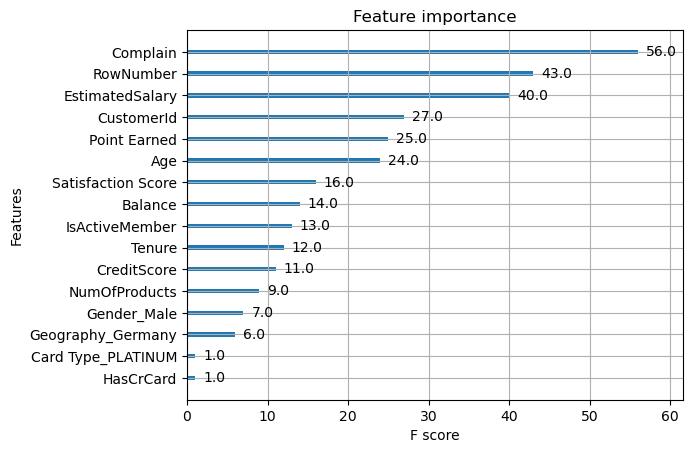

In [211]:
plot_importance(xgb_cv_res.best_estimator_)

In [189]:
model_res = Sequential()

#input layer
model_res.add(Dense(units=32, activation='relu', input_dim=len(X_train_res.columns)))
#hidden layer
model_res.add(Dense(units=64, activation='relu'))
model_res.add(Dense(units=64, activation='relu'))
#output layer
model_res.add(Dense(units=1, activation='sigmoid'))


C:\Users\Lim Otto\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [190]:
#Compile 2nd model_res
model_res.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [192]:
#Fit neural network with processed data

model_res.fit(X_train_res, y_train_res, epochs=200, batch_size=32, callbacks=[early_stopping]) 

Epoch 1/200
374/374 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.4944 - loss: 14975.7783
Epoch 2/200


C:\Users\Lim Otto\anaconda3\Lib\site-packages\keras\src\callbacks\early_stopping.py:155: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


374/374 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5129 - loss: 1215.6099
Epoch 3/200
374/374 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5086 - loss: 858.5478
Epoch 4/200
374/374 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5139 - loss: 762.8942
Epoch 5/200
374/374 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5046 - loss: 442.9040
Epoch 6/200
374/374 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5313 - loss: 274.5022
Epoch 7/200
374/374 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5247 - loss: 211.6645
Epoch 8/200
374/374 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5282 - loss: 165.1340
Epoch 9/200
374/374 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5079 - loss: 88.4862
Epoch 10/200
374/374 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5104 - loss: 47.5569
Epoch 11/200
374/374 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5122 - loss: 27.2633
Epoch 12/200
374/374 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5023 - loss: 81.3637
Epoch 13/200
374/374 ━━━━━━━━━━━━

374/374 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5002 - loss: 0.6932
Epoch 70/200
374/374 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4982 - loss: 0.6932
Epoch 71/200
374/374 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4898 - loss: 0.6932
Epoch 72/200
374/374 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4979 - loss: 0.6932
Epoch 73/200
374/374 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4940 - loss: 0.6932
Epoch 74/200
374/374 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5015 - loss: 0.6931
Epoch 75/200
374/374 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5030 - loss: 0.6932
Epoch 76/200
374/374 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5057 - loss: 0.6932
Epoch 77/200
374/374 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4996 - loss: 0.6932
Epoch 78/200
374/374 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5019 - loss: 0.6932
Epoch 79/200
374/374 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5021 - loss: 0.6932
Epoch 80/200
374/374 ━━━━━━━━━━━━━━━━━━━━ 2s 

374/374 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5043 - loss: 0.6932
Epoch 136/200
374/374 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5005 - loss: 0.6932
Epoch 137/200
374/374 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4908 - loss: 0.6932
Epoch 138/200
374/374 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5067 - loss: 0.6931
Epoch 139/200
374/374 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5022 - loss: 0.6932
Epoch 140/200
374/374 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4963 - loss: 0.6932
Epoch 141/200
374/374 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5035 - loss: 0.6931
Epoch 142/200
374/374 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4901 - loss: 0.6932
Epoch 143/200
374/374 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4904 - loss: 0.6932
Epoch 144/200
374/374 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4863 - loss: 0.6932
Epoch 145/200
374/374 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5067 - loss: 0.6932
Epoch 146/200
374/374 ━━━━━━━━━━━━━

In [193]:
tf_res_pred = model_res.predict(X_test)
tf_res_pred = [0 if val <0.5 else 1 for val in tf_res_pred]

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [194]:
print('Accuracy score:', accuracy_score(y_test, tf_res_pred))
print('Precision score:', precision_score(y_test, tf_res_pred))
print('Recall score:', recall_score(y_test, tf_res_pred))
print('F1 score:', f1_score(y_test, tf_res_pred))

Accuracy score: 0.6804
Precision score: 0.3024523160762943
Recall score: 0.4361493123772102
F1 score: 0.3572003218020917


In [207]:
tf_val_accuracy = accuracy_score(y_test, tf_res_pred)
tf_val_precision =  precision_score(y_test, tf_res_pred)
tf_val_recall = recall_score(y_test, tf_res_pred)
tf_val_f1 = f1_score(y_test, tf_res_pred)
tf_val_results = pd.DataFrame({'Model':[model_res],
                          'F1': [tf_val_f1],
                          'Recall': [tf_val_recall],
                          'Precision': [tf_val_precision],
                          'Accuracy': [tf_val_accuracy]})
tf_val_results

,Model,F1,Recall,Precision,Accuracy
0,"<Sequential name=sequential_2, built=True>",0.3572,0.436149,0.302452,0.6804


## Results comparison between models before and after upsampling and scaled

In [209]:
#concat and compare all resampled and scaled result from earlier ML models
all_res_results = pd.concat([rf_cv_res_table, rf_val_results, xgb_res_result, tf_val_results], ignore_index=True)
all_res_results

,Model,F1,Recall,Precision,Accuracy
0,RF Res,0.938388,0.942743,0.942371,0.940638
1,"(DecisionTreeClassifier(max_depth=2, max_featu...",0.951515,0.925344,0.979210,0.980800
2,XGBoost,0.998576,0.998493,0.998660,0.998576
3,"<Sequential name=sequential_2, built=True>",0.357200,0.436149,0.302452,0.680400


In [210]:
all_results

,Model,F1,Recall,Precision,Accuracy
0,Tuned Tree,0.996736,0.998693,0.99479,0.998667
1,Random Forest,0.000000,0.000000,0.00000,0.796133
2,Random Forest Tuned,0.000000,0.000000,0.00000,0.796267
3,XGBoost,0.996736,0.998693,0.99479,0.998667
4,"<Sequential name=sequential_1, built=True>",0.000000,0.000000,0.00000,0.796400


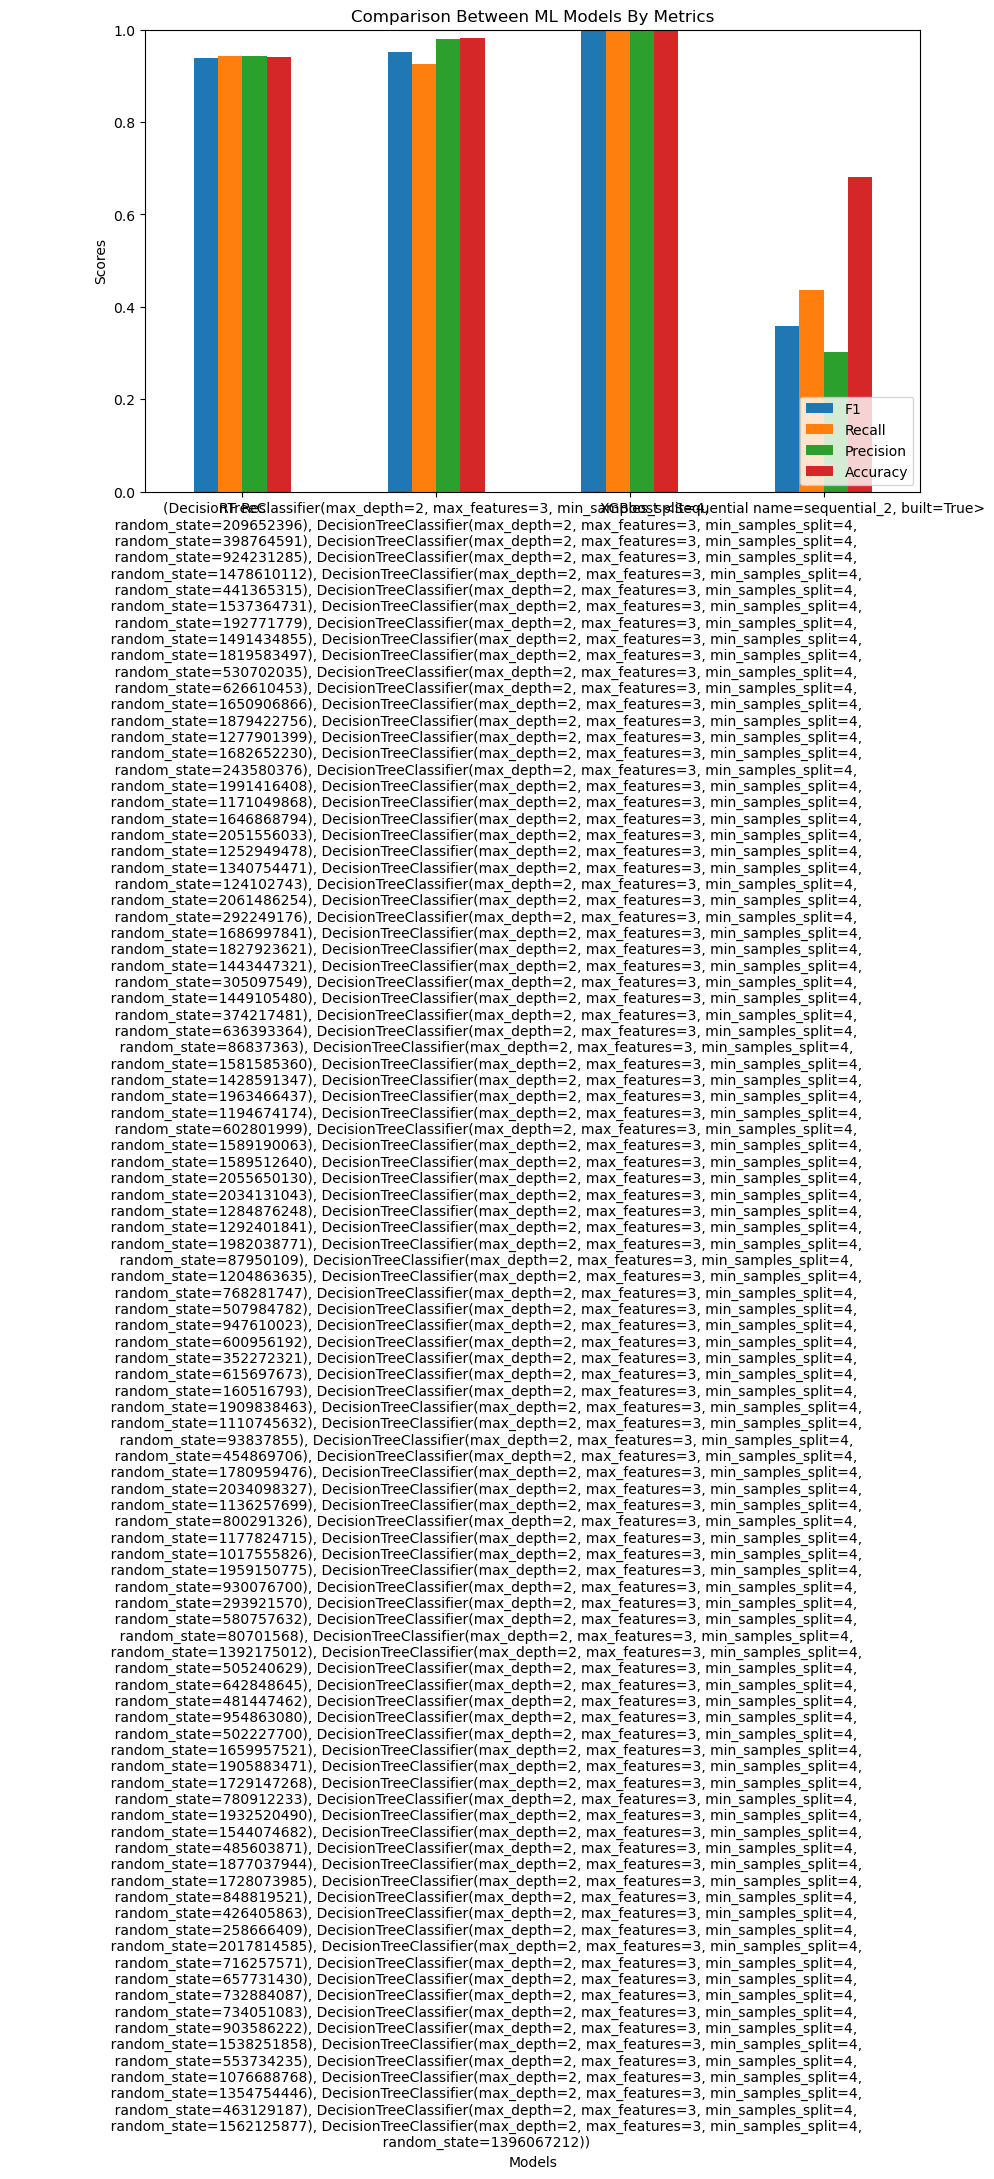

In [219]:
all_res_results.plot(kind='bar', figsize=(10, 6))
plt.title('Comparison Between ML Models By Metrics')
plt.xlabel('Models')
plt.ylabel('Scores')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.xticks(rotation=0)
plt.show()

### Results shows significant improvement around metrics after resampling and scaling
### Reason being class imbalance which model fails to predict the minority class, resilting 0 in few metrics

## Conclusion

#### Based on our chosen metric F1 score, XGBoost (resampled) model peforms the best at F1 score at 0.998, followed closely in 2nd place Tuned Decision Tree model peforming at 0.996